# Bilimsel Çelişki Tespit — Saf Bilimsel Veri Sürümü

Ana notebook (~559k karışık NLI) yerine **sadece bilimsel makale tabanlı** veri kullanır:
- **Eğitim:** SciNLI (ACL Anthology paper'larından, 101k çift, tam)
- **Test:** SciFact (bilimsel claim+abstract, ~519 çift)
- **Domain adaptation:** SciFact train (1261 çift)

Felsefe: veri **boyutu yerine domain match**. Daha hızlı, daha hedeflenmiş.

Çıktı modeli: `models/contradiction_model_sci/` (ayrı klasör, ana modele dokunmaz).

## Hücre 1 — Setup

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import torch
import torch.nn as nn
import torch.nn.functional as F

import sys, json, time, random, logging
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("sci")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}")

c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5080 Laptop GPU | CUDA: 12.8


## Hücre 2 — Config

In [2]:
CONFIG = {
    "base_model": "./models/scibert",
    "max_length": 256,
    "batch_size": 32,
    "learning_rate": 2e-5,
    "num_epochs": 3,                    # 101k veri için 3 epoch makul
    "warmup_steps": 200,
    "weight_decay": 0.01,
    "fp16": True,
    "output_dir": "./models/contradiction_model_sci",
    "cache_dir": "./cache",
    "hf_cache": "./cache/hf",
}
for k in ("output_dir", "cache_dir", "hf_cache"):
    Path(CONFIG[k]).mkdir(parents=True, exist_ok=True)

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

ID2LABEL = {0: "SUPPORT", 1: "NEUTRAL", 2: "CONTRADICT"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
LABEL2SCORE = {0: 0.0, 1: 0.5, 2: 1.0}

print(json.dumps(CONFIG, indent=2))

{
  "base_model": "./models/scibert",
  "max_length": 256,
  "batch_size": 32,
  "learning_rate": 2e-05,
  "num_epochs": 3,
  "warmup_steps": 200,
  "weight_decay": 0.01,
  "fp16": true,
  "output_dir": "./models/contradiction_model_sci",
  "cache_dir": "./cache",
  "hf_cache": "./cache/hf"
}


## Hücre 3 — SciNLI yükle (sadece bilimsel)

SciNLI 4 sınıflı: `entailment, neutral, reasoning, contrasting` → 3 sınıfa indir.
Train (~101k) + native validation (~2k).

In [3]:
from datasets import load_dataset

def map_label(raw) -> Optional[int]:
    if raw is None: return None
    if isinstance(raw, (int, np.integer)):
        v = int(raw); return v if v in (0,1,2) else None
    s = str(raw).lower().strip()
    if s in {"entailment","entail","0","support","supports"}:                return 0
    if s in {"neutral","reasoning","1","nei","not enough info"}:             return 1
    if s in {"contradiction","contrasting","contradict","2","refutes"}:      return 2
    return None

def pick_fields(ex):
    for a,b in [("premise","hypothesis"),("sentence1","sentence2"),("text_a","text_b")]:
        if a in ex and b in ex: return a,b
    return None,None

ds = load_dataset("tasksource/scinli", cache_dir=CONFIG["hf_cache"])
print("Splits:", list(ds.keys()), "| boyutlar:", {k: len(v) for k,v in ds.items()})

def to_df(split):
    rows = []
    a,b = pick_fields(split[0])
    for ex in split:
        lab = map_label(ex.get("label"))
        if lab is None: continue
        p = (ex.get(a) or "").strip(); h = (ex.get(b) or "").strip()
        if len(p) < 5 or len(h) < 5: continue
        rows.append({"premise":p, "hypothesis":h, "label":lab})
    return pd.DataFrame(rows)

train_df = to_df(ds["train"])
val_df   = to_df(ds["validation"]) if "validation" in ds else to_df(ds.get("test", ds["train"]))

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}")
print("Train sınıf dağılımı:")
print(train_df["label"].map(ID2LABEL).value_counts())

2026-06-02 15:22:32,099 INFO PyTorch version 2.11.0+cu128 available.
Using the latest cached version of the dataset since tasksource/scinli couldn't be found on the Hugging Face Hub (offline mode is enabled).
2026-06-02 15:22:33,411 WARNING Using the latest cached version of the dataset since tasksource/scinli couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at cache\hf\tasksource___scinli\default\0.0.0\61419d7f2cec9ca67324f28f6a077582643a037c (last modified on Fri May 22 14:18:00 2026).
2026-06-02 15:22:33,413 WARNING Found the latest cached dataset configuration 'default' at cache\hf\tasksource___scinli\default\0.0.0\61419d7f2cec9ca67324f28f6a077582643a037c (last modified on Fri May 22 14:18:00 2026).


Splits: ['train', 'validation', 'test'] | boyutlar: {'train': 101412, 'validation': 2000, 'test': 4000}

Train: 101412  Val: 2000
Train sınıf dağılımı:
label
NEUTRAL       50706
CONTRADICT    25353
SUPPORT       25353
Name: count, dtype: int64


## Hücre 4 — Tokenize

In [4]:
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset, load_from_disk

tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"])

def to_hf(df):
    return Dataset.from_pandas(df[["premise","hypothesis","label"]], preserve_index=False)

def tok(batch):
    enc = tokenizer(batch["premise"], batch["hypothesis"],
                    max_length=CONFIG["max_length"], truncation=True,
                    padding="max_length")
    enc["labels"] = batch["label"]; return enc

TOK_DIR = Path(CONFIG["cache_dir"]) / "tokenized_sci"
if (TOK_DIR/"train").exists() and (TOK_DIR/"val").exists():
    tk = {s: load_from_disk(str(TOK_DIR/s)) for s in ["train","val"]}
    log.info("Tokenize cache'den")
else:
    tk = {}
    for name, df in [("train",train_df),("val",val_df)]:
        d = to_hf(df).map(tok, batched=True, remove_columns=["premise","hypothesis","label"])
        d.save_to_disk(str(TOK_DIR/name)); tk[name] = d
    log.info("Tokenize tamam")
print({k: len(v) for k,v in tk.items()})

c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Saving the dataset (1/1 shards): 100%|██████████| 2000/2000 [00:00<00:00, 500364.33 examples/s]
2026-06-02 15:22:42,648 INFO Tokenize tamam


{'train': 101412, 'val': 2000}


## Hücre 5 — Model (SciBERT + 3-class head)

In [5]:
class ContradictionDetector(nn.Module):
    def __init__(self, base=CONFIG["base_model"], n_labels=3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(nn.Dropout(0.1), nn.Linear(h, n_labels))
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kw):
        kw_in = {"input_ids":input_ids, "attention_mask":attention_mask}
        if token_type_ids is not None: kw_in["token_type_ids"] = token_type_ids
        out = self.encoder(**kw_in)
        logits = self.classifier(out.last_hidden_state[:,0,:])
        loss = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {"loss":loss, "logits":logits}
    def gradient_checkpointing_enable(self, **kw):  self.encoder.gradient_checkpointing_enable(**kw)
    def gradient_checkpointing_disable(self):       self.encoder.gradient_checkpointing_disable()

model = ContradictionDetector()
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 109,920,771


## Hücre 6 — Eğitim (~15 dk)

101k örnek × 3 epoch / batch=32 ≈ 9500 step, RTX 5080 @ ~10 it/s → ~15 dk.

In [6]:
from sklearn.metrics import (r2_score, accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

def score_from_probs(probs): return probs[:,2] + 0.5*probs[:,1]

def compute_metrics(ep):
    logits, labels = ep
    probs = torch.softmax(torch.from_numpy(np.asarray(logits)), dim=-1).numpy()
    preds = probs.argmax(-1)
    y_p = score_from_probs(probs)
    y_t = np.array([LABEL2SCORE[int(l)] for l in labels])
    return {"r2":r2_score(y_t, y_p),
            "accuracy":accuracy_score(labels, preds),
            "f1_macro":f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"]*2,
    learning_rate=CONFIG["learning_rate"],
    num_train_epochs=CONFIG["num_epochs"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    fp16=CONFIG["fp16"] and torch.cuda.is_available(),
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, logging_steps=200,
    save_safetensors=False, report_to="none", seed=SEED,
)
trainer = Trainer(
    model=model, args=args,
    train_dataset=tk["train"], eval_dataset=tk["val"],
    tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
t0 = time.time()
trainer.train()
log.info("Eğitim süresi: %.1f dk", (time.time()-t0)/60)

c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\accelerate\accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
  2%|▏         | 201/9510 [00:28<21:46,  7.13it/s]

{'loss': 0.9011, 'grad_norm': 9.341608047485352, 'learning_rate': 1.98e-05, 'epoch': 0.06}


  4%|▍         | 401/9510 [00:57<21:54,  6.93it/s]

{'loss': 0.6995, 'grad_norm': 7.2579522132873535, 'learning_rate': 1.957465091299678e-05, 'epoch': 0.13}


  6%|▋         | 601/9510 [01:25<21:26,  6.93it/s]

...

{'loss': 0.2688, 'grad_norm': 7.866011619567871, 'learning_rate': 2.4704618689581094e-07, 'epoch': 2.97}


                                                   
100%|██████████| 9510/9510 [24:33<00:00,  6.41it/s]

{'eval_loss': 0.5467560887336731, 'eval_r2': 0.5942206230061549, 'eval_accuracy': 0.8185, 'eval_f1_macro': 0.8104661182635496, 'eval_runtime': 3.2146, 'eval_samples_per_second': 622.157, 'eval_steps_per_second': 9.955, 'epoch': 3.0}


100%|██████████| 9510/9510 [24:35<00:00,  6.45it/s]
2026-06-02 15:47:22,828 INFO Eğitim süresi: 24.6 dk


{'train_runtime': 1475.5009, 'train_samples_per_second': 206.192, 'train_steps_per_second': 6.445, 'train_loss': 0.45088835815525957, 'epoch': 3.0}


## Hücre 7 — SciFact test (genel hâl, adaptation öncesi)

Ana notebook'taki ile aynı SciFact pair builder.

In [7]:
SCIFACT_LABEL = {"SUPPORT": 0, "CONTRADICT": 2}

def build_scifact_pairs(split_name="validation"):
    claims = load_dataset("allenai/scifact","claims",cache_dir=CONFIG["hf_cache"],trust_remote_code=True)
    corpus = load_dataset("allenai/scifact","corpus",cache_dir=CONFIG["hf_cache"],trust_remote_code=True)["train"]
    doc_lookup = {int(r["doc_id"]): " ".join(r["abstract"]) for r in corpus}
    rows = []
    for ex in claims[split_name]:
        ev_doc   = (ex.get("evidence_doc_id") or "").strip()
        ev_label = (ex.get("evidence_label") or "").strip()
        cited    = list(ex.get("cited_doc_ids") or [])
        claim    = ex["claim"]
        if ev_label in SCIFACT_LABEL and ev_doc:
            ab = doc_lookup.get(int(ev_doc))
            if ab: rows.append({"premise":ab,"hypothesis":claim,"label":SCIFACT_LABEL[ev_label]})
            for cd in [c for c in cited if str(c) != ev_doc][:1]:
                a2 = doc_lookup.get(int(cd))
                if a2: rows.append({"premise":a2,"hypothesis":claim,"label":1})
        else:
            for cd in cited:
                a2 = doc_lookup.get(int(cd))
                if a2: rows.append({"premise":a2,"hypothesis":claim,"label":1}); break
    return pd.DataFrame(rows)

scifact_test_df = build_scifact_pairs("validation")
print("SciFact test sınıf dağılımı:")
print(scifact_test_df["label"].map(ID2LABEL).value_counts())

test_ds = to_hf(scifact_test_df).map(tok, batched=True,
                remove_columns=["premise","hypothesis","label"])

pred = trainer.predict(test_ds)
probs = torch.softmax(torch.from_numpy(pred.predictions), dim=-1).numpy()
preds = probs.argmax(-1); labels = pred.label_ids
r2_g  = r2_score(np.array([LABEL2SCORE[int(l)] for l in labels]), score_from_probs(probs))
acc_g = accuracy_score(labels, preds)
f1m_g = f1_score(labels, preds, average="macro")
print(f"\n=== SciFact TEST (SciNLI-only) ===\nR² {r2_g:.4f} | Acc {acc_g:.4f} | F1 {f1m_g:.4f}")
print(classification_report(labels, preds, target_names=[ID2LABEL[i] for i in range(3)], digits=3, zero_division=0))

Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-06-02 15:47:22,851 WARNING Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-06-02 15:47:22,879 WARNING Using the latest cached version of the 

SciFact test sınıf dağılımı:
label
SUPPORT       216
NEUTRAL       181
CONTRADICT    122
Name: count, dtype: int64


100%|██████████| 9/9 [00:00<00:00, 13.13it/s]


=== SciFact TEST (SciNLI-only) ===
R² -0.0286 | Acc 0.4393 | F1 0.3609
              precision    recall  f1-score   support

     SUPPORT      0.500     0.569     0.532       216
     NEUTRAL      0.387     0.541     0.452       181
  CONTRADICT      0.350     0.057     0.099       122

    accuracy                          0.439       519
   macro avg      0.412     0.389     0.361       519
weighted avg      0.425     0.439     0.402       519



## Hücre 8 — Yedek + SciFact train ile domain adaptation (1 dk)

In [8]:
import shutil
save_dir = Path(CONFIG["output_dir"])
backup_dir = save_dir.parent / "contradiction_model_sci_general"
backup_dir.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), backup_dir / "pytorch_model.bin")
tokenizer.save_pretrained(backup_dir)
with open(backup_dir/"metrics.json","w") as f:
    json.dump({"r2":float(r2_g),"accuracy":float(acc_g),"f1_macro":float(f1m_g)}, f, indent=2)
print(f"Yedek (SciNLI-only): {backup_dir}")

# Domain adaptation: SciFact train
scifact_train_df = build_scifact_pairs("train")
print("\nSciFact train sınıf dağılımı:")
print(scifact_train_df["label"].map(ID2LABEL).value_counts())
sci_train_ds = to_hf(scifact_train_df).map(tok, batched=True,
                    remove_columns=["premise","hypothesis","label"])

adapt_args = TrainingArguments(
    output_dir=str(save_dir / "_adapt"),
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=1e-5,                 # düşük lr -> catastrophic forgetting az
    num_train_epochs=3,                 # 3 epoch yeterli (10 epoch overfit ediyor)
    warmup_steps=50, weight_decay=0.01, fp16=True,
    eval_strategy="epoch", save_strategy="no",
    logging_steps=20, save_safetensors=False, report_to="none", seed=SEED,
)
adapt_trainer = Trainer(
    model=model, args=adapt_args,
    train_dataset=sci_train_ds, eval_dataset=test_ds,
    tokenizer=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
t0 = time.time()
adapt_trainer.train()
log.info("Adaptation süresi: %.1f dk", (time.time()-t0)/60)

Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-06-02 15:47:24,692 WARNING Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
Using the latest cached version of the module from C:\Users\ugras\.cache\huggingface\modules\datasets_modules\datasets\allenai--scifact\15660e43ecfb3f7420850027005a63611abb2d401e9746b4059c1260745d9831 (last modified on Fri May 22 09:38:21 2026) since it couldn't be found locally at allenai/scifact
2026-06-02 15:47:24,709 WARNING Using the latest cached version of the 

Yedek (SciNLI-only): models\contradiction_model_sci_general

SciFact train sınıf dağılımı:
label
SUPPORT       616
NEUTRAL       506
CONTRADICT    341
Name: count, dtype: int64


Map: 100%|██████████| 1463/1463 [00:00<00:00, 2556.13 examples/s]
c:\Users\ugras\Desktop\atif_ai\.venv\Lib\site-packages\accelerate\accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
  8%|▊         | 21/276 [00:01<00:22, 11.49it/s]

{'loss': 1.1108, 'grad_norm': 10.730997085571289, 'learning_rate': 3.4000000000000005e-06, 'epoch': 0.22}


 15%|█▍        | 41/276 [00:03<00:20, 11.44it/s]

...

{'loss': 0.4252, 'grad_norm': 7.444957256317139, 'learning_rate': 1.7256637168141593e-06, 'epoch': 2.61}


 95%|█████████▍| 261/276 [00:24<00:01, 11.21it/s]

{'loss': 0.4941, 'grad_norm': 12.312111854553223, 'learning_rate': 8.4070796460177e-07, 'epoch': 2.83}


100%|██████████| 276/276 [00:26<00:00, 10.39it/s]
2026-06-02 15:47:52,403 INFO Adaptation süresi: 0.4 dk


{'eval_loss': 0.9562035799026489, 'eval_r2': 0.03707587856167993, 'eval_accuracy': 0.6204238921001927, 'eval_f1_macro': 0.6014778368920591, 'eval_runtime': 0.7951, 'eval_samples_per_second': 652.766, 'eval_steps_per_second': 21.382, 'epoch': 3.0}
{'train_runtime': 26.5524, 'train_samples_per_second': 165.296, 'train_steps_per_second': 10.395, 'train_loss': 0.6725630190061487, 'epoch': 3.0}


## Hücre 9 — Adapte model: değerlendir, karşılaştır, kaydet

100%|██████████| 17/17 [00:00<00:00, 22.06it/s]


Metrik        SciNLI-only       + SciFact adapt     Δ
------------------------------------------------------------
R²            -0.0286           0.0371              ↑ +0.0657
Accuracy      0.4393            0.6204              ↑ +0.1811
F1 macro      0.3609            0.6015              ↑ +0.2406
              precision    recall  f1-score   support

     SUPPORT      0.665     0.644     0.654       216
     NEUTRAL      0.696     0.696     0.696       181
  CONTRADICT      0.442     0.467     0.454       122

    accuracy                          0.620       519
   macro avg      0.601     0.602     0.601       519
weighted avg      0.623     0.620     0.622       519



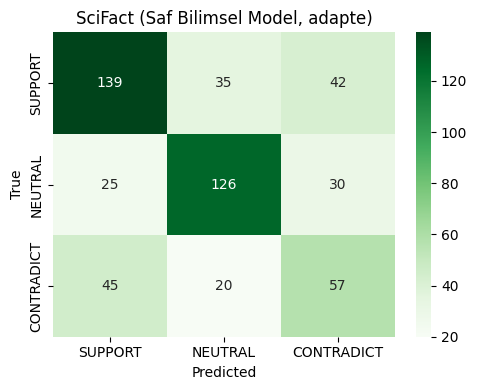


Kaydedildi: models\contradiction_model_sci
Yedek (SciNLI-only): models\contradiction_model_sci_general


In [9]:
pred_a = adapt_trainer.predict(test_ds)
probs_a = torch.softmax(torch.from_numpy(pred_a.predictions), dim=-1).numpy()
preds_a = probs_a.argmax(-1); labels_a = pred_a.label_ids
r2_a  = r2_score(np.array([LABEL2SCORE[int(l)] for l in labels_a]), score_from_probs(probs_a))
acc_a = accuracy_score(labels_a, preds_a)
f1m_a = f1_score(labels_a, preds_a, average="macro")

print("="*60)
print(f"{'Metrik':<14}{'SciNLI-only':<18}{'+ SciFact adapt':<20}{'Δ'}")
print("-"*60)
for name, old, new in [("R²",r2_g,r2_a),("Accuracy",acc_g,acc_a),("F1 macro",f1m_g,f1m_a)]:
    d = new - old; ar = "↑" if d>0 else ("↓" if d<0 else "·")
    print(f"{name:<14}{old:<18.4f}{new:<20.4f}{ar} {d:+.4f}")
print("="*60)
print(classification_report(labels_a, preds_a,
        target_names=[ID2LABEL[i] for i in range(3)], digits=3, zero_division=0))

cm = confusion_matrix(labels_a, preds_a, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=[ID2LABEL[i] for i in range(3)],
    yticklabels=[ID2LABEL[i] for i in range(3)], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("SciFact (Saf Bilimsel Model, adapte)")
plt.tight_layout(); plt.show()

# Final kayıt
torch.save(model.state_dict(), save_dir / "pytorch_model.bin")
tokenizer.save_pretrained(save_dir)
with open(save_dir/"config.json","w") as f:
    json.dump({"base_model":CONFIG["base_model"],"label2id":LABEL2ID,
               "id2label":ID2LABEL,"max_length":CONFIG["max_length"],
               "training_data":"SciNLI (101k) + SciFact adapt (1261)"}, f, indent=2)
with open(save_dir/"metrics.json","w") as f:
    json.dump({"r2":float(r2_a),"accuracy":float(acc_a),"f1_macro":float(f1m_a)}, f, indent=2)
print(f"\nKaydedildi: {save_dir}")
print(f"Yedek (SciNLI-only): {backup_dir}")